<a href="https://colab.research.google.com/github/JanethGrimaldo/AI/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Artificial Intelligence Final Project
---


**Team Members:**

*Alejandra Janeth Hernández Grimaldo 1929944*

*Ximena Arellano Arellano 2055629*

*Camila Andrea Silva Espinoza 2109522*

*Jorge Alfonso García Rodriguez 2132194*

---

**Career:** Biomedical Engineering

**Group:** 002

**Professor:** Daniel Isaías López Páez

**Hour:** Thursday N4-N6

---




# Introduction
---


# Methodology
---


## 1. Import libraries


---
This section loads all the necessary libraries and modules used throughout the project:






- For building and training deep learning models, especially Convolutional Neural Networks (CNNs).



In [28]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models


- For plotting images and visualizing model predictions and metrics

In [29]:
import matplotlib.pyplot as plt

- For loading datasets from Kaggle directly into the workspace

In [30]:
import kagglehub

- For image processing tasks such as resizing, converting color formats, etc.

In [31]:
import cv2

-  For file path handling and retrieving image files from directories.

In [32]:
import os
import glob

- For numerical operations and handling image data as arrays

In [33]:
import numpy as np

- To split the dataset into training and testing subsets

In [34]:
from sklearn.model_selection import train_test_split

**Keras Utilities**
- to convert class labels to one-hot encoding format.
- Perform data augmentation to increase dataset size and diversity.
- Define a linear stack of neural network layers.

In [36]:

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense, Dropout, BatchNormalization


## 2. Preprocessing

In [8]:
path = kagglehub.dataset_download("mohamedhanyyy/chest-ctscan-images")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/chest-ctscan-images


In [9]:
def create_data(subset_path):
    data = []
    labels = []
    classes = os.listdir(subset_path)

    for class_index, class_name in enumerate(classes):
        class_dir = os.path.join(subset_path, class_name)
        if not os.path.isdir(class_dir):
            continue
        image_list = glob.glob(os.path.join(class_dir, '*'))
        for img_path in image_list:
            try:
                image = cv2.imread(img_path)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, (224, 224))
                data.append(image)
                labels.append(class_index)
            except:
                print(f"Error leyendo {img_path}")
    return np.array(data), np.array(labels)

train_path = os.path.join(path, "Data", "train")

data, labels = create_data(train_path)

data = data / 255.0

print("Data Shape:", data.shape)
print("Labels Shape:", labels.shape)


Data Shape: (613, 224, 224, 3)
Labels Shape: (613,)


# 3. Model Selection and Training

In [10]:
labels = to_categorical(labels)

(x_train, x_test, y_train, y_test) = train_test_split(
    data,
    labels,
    test_size=0.20,
    stratify=labels,
    random_state=42
)

trainAug = ImageDataGenerator(
    rotation_range=15,
    fill_mode="nearest"
)

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(490, 224, 224, 3)
(490, 4)
(123, 224, 224, 3)
(123, 4)


In [22]:
INP_SIZE = (224, 224, 3)
BATCH_SIZE = 32
EPOCHS = 20

model = Sequential()
model.add(BatchNormalization(input_shape=INP_SIZE))
model.add(Conv2D(16, kernel_size=(3,3), padding='same', activation='relu'))
model.add(Conv2D(16, kernel_size=(3,3), padding='same', activation='relu'))
model.add(AveragePooling2D(pool_size=(2,2)))
model.add(Dropout(0.35))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.35))
model.add(Dense(4, activation='softmax'))


In [23]:
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [24]:
history = model.fit(
    trainAug.flow(x_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=len(x_train) // BATCH_SIZE,
    validation_data=(x_test, y_test),
    validation_steps=len(x_test) // BATCH_SIZE,
    epochs=EPOCHS
)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.3387 - loss: 7.5977 - val_accuracy: 0.2439 - val_loss: 1.3343
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 202ms/step - accuracy: 0.5000 - loss: 1.2195 - val_accuracy: 0.2439 - val_loss: 1.3361
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.5680 - loss: 1.0528 - val_accuracy: 0.2439 - val_loss: 1.2807
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step - accuracy: 0.4000 - loss: 1.0115 - val_accuracy: 0.2602 - val_loss: 1.2737
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - accuracy: 0.6098 - loss: 0.9095 - val_accuracy: 0.3984 - val_loss: 1.1986
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 184ms/step - accuracy: 0.5938 - loss: 0.7816 - val_accuracy: 0.4065 - val_loss: 1.1932
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.6743 - loss: 0.7322 - val_accuracy: 0.5528 - val_loss: 1.0835
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 186ms/step - accuracy: 0.7500 - loss: 0.5726 - val_accuracy: 0.5528 - v

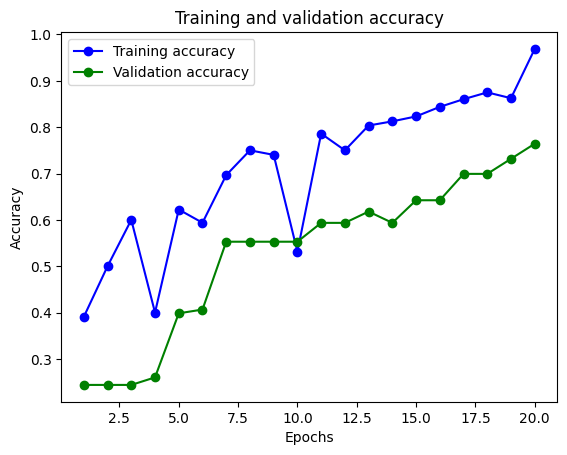

In [25]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plotting the accuracy and validation accuracy
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo-', label='Training accuracy')
plt.plot(epochs, val_acc, 'go-', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step


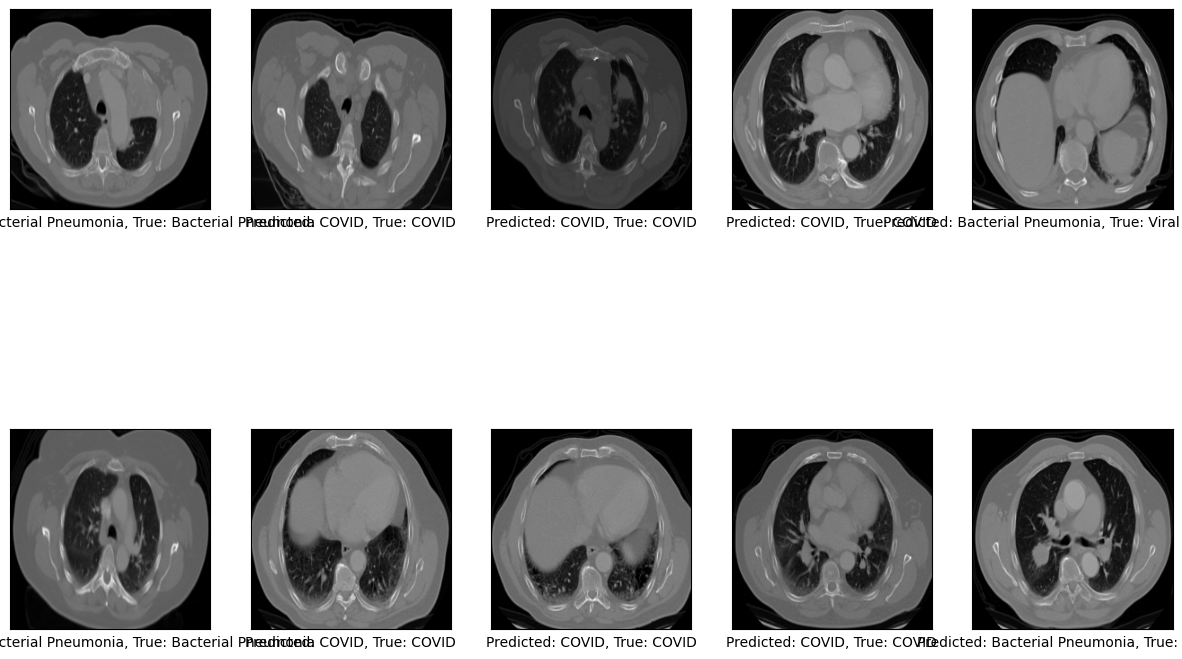

In [27]:
# Predict on a subset of test data
num_images = 10
test_subset = x_test[:num_images]
true_labels = np.argmax(y_test[:num_images], axis=1)

# Make predictions
predictions = model.predict(test_subset)
predicted_classes = np.argmax(predictions, axis=1)

# Label mapping
label_map = {
    0: 'COVID',
    1: 'Normal',
    2: 'Viral Pneumonia',
    3: 'Bacterial Pneumonia'
}
true_labels_str = [label_map[label] for label in true_labels]
predicted_classes_str = [label_map[label] for label in predicted_classes]

# Plotting the first 10 test images with their predicted and true labels
plt.figure(figsize=(15, 10))
for i in range(num_images):
    plt.subplot(2, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(test_subset[i], cmap=plt.cm.binary)  # Assuming images are grayscale, change if necessary
    plt.xlabel(f"Predicted: {predicted_classes_str[i]}, True: {true_labels_str[i]}")
plt.show()


# Results
---


# General Conclusion

---


# References

---
1. Matthes, E. (2023). Python crash course. No starch press.

https://www.w3schools.com/python/default.asp

2. Géron, A. (2022). Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow. " O'Reilly Media, Inc."